---
title: "Volatility Forecasts (Part 5 — PGARCH)"
date: 2026-03-10
description: "Part 5 revisits the three-feature PGARCH stage: with only fast return features, a dynamic long-run anchor is hard to interpret, so the cleaner specification keeps mu constant and lets persistence and shock loading adapt."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
content-type: "series"
series-id: "volatility-forecasting"
series-title: "Volatility Forecasts"
series-part: 5
project-ids: [volatility-forecasting]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---


## Introduction

In [Part 4](../volatility-forecasts-4/) we found that in our rather limited SPY variance forecasting benchmark, **GARCH(1,1)** dominated the STES family under out-of-sample QLIKE even though the STES variants had more flexible predictor-driven gates. That result suggested that the real advantage for GARCH(1,1) was perhaps structural. GARCH separates an anchor, a persistence term, and a shock-transmission term, whereas STES-family has only a shock-transmission term, albeit a dynamic one. The question now is whether we can generalize GARCH(1,1) to use predictor-driven gate, and if this will deliver better results.

A natural first generalization is the unrestricted three-feature PGARCH specification in which all three channels--the anchor, persistence, and shock-transmission term--or $(\mu_t, \phi_t, g_t)$, vary with lagged return information. Those unrestricted models remain useful comparison points in this post. We keep our information set to the same ones we used in Part 4: lagged return, lagged absolute return, and lagged squared return. Those are all fast shock-sensitive features. They are plausible drivers of short-run persistence and shock loading, but they do not give a clean basis for a time-varying long-run variance channel. Therefore we also test other variants in which we keep the anchor a constant, for example.

This post keeps the dataset, target definition, train/test split, QLIKE evaluation, DM-test protocol, and `GARCH(1,1)` benchmark fixed. We want to determine if the same information set supports a **time-varying or constant long-run anchor** with **time-varying persistence** and **time-varying shock loading**.

The implementation for the models discussed within this post can be found in the [`volatility-forecast`](https://github.com/steveya/volatility-forecast) package: the linear restrictions are in `volatility_forecast/model/pgarch_linear_model.py`, and the boosted `g` extension remains in `volatility_forecast/model/xgb_pgarch_model.py`. The discussion here uses that code under the fixed SPY split and the same QLIKE/DM protocol from Part 4.


In [16]:
#| echo: false
#| output: false

import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- PATH SETUP ---
def _find_workspace_root(start: Path) -> Path:
    required = ("steveya.github.io", "volatility-forecast", "alphaforge")
    for candidate in (start, *start.parents):
        if all((candidate / name).exists() for name in required):
            return candidate
    raise RuntimeError(
        f"Could not locate workspace root from {start}. Expected sibling repos: {required}"
    )


WORKSPACE_ROOT = _find_workspace_root(Path.cwd().resolve())
BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / ".env")
# --- LIBRARY IMPORTS ---
from alphaforge.data.cache import FileCacheBackend
from volatility_forecast.pipeline import build_default_ctx, build_vol_dataset, VolDatasetSpec
from volatility_forecast.evaluation.metrics import rmse, qlike
from volatility_forecast.evaluation.dm_test import diebold_mariano

from volatility_forecast.model.pgarch_linear_model import PGARCHLinearModel
from volatility_forecast.model.xgb_pgarch_model import XGBGPGARCHModel

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style,
)

# --- CACHE ---
SCRIPT_CACHE_DIR = VF_PATH / ".af_cache"
SCRIPT_CACHE_MODE = "use"

# --- STYLES ---
inject_blog_table_css()
apply_blog_plot_style()

# --- DATA CONTEXT ---
cache = FileCacheBackend(SCRIPT_CACHE_DIR)
print(f"Tiingo cache dir: {SCRIPT_CACHE_DIR}")
print(f"Tiingo cache mode: {SCRIPT_CACHE_MODE}")

Tiingo cache dir: /Users/steveyang/Projects/steveya/volatility-forecast/.af_cache
Tiingo cache mode: use


In [17]:
#| echo: false
#| output: false

from arch import arch_model
from alphaforge.features.dataset_spec import (
    UniverseSpec, TimeSpec, FeatureRequest, TargetRequest, JoinPolicy, MissingnessPolicy,
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate, LagAbsLogReturnTemplate, LagSquaredLogReturnTemplate,
)
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget

# --- SAMPLE PARAMETERS (identical to Part 4) ---
SAMPLE_TICKER = "SPY"
SAMPLE_START = pd.Timestamp("2000-01-01", tz="UTC")
SAMPLE_END = pd.Timestamp("2023-12-31", tz="UTC")
SAMPLE_TRAIN_START = 200
SAMPLE_SPLIT_INDEX = 4000
SCALE_FACTOR = 100.0

# --- CACHE PREFLIGHT ---
sample_cache_key = f"{SAMPLE_TICKER}|adj=True"
sample_cached = cache.get(sample_cache_key)
if sample_cached is None or sample_cached.empty:
    raise RuntimeError(f"Cache-only mode: no cached data for key={sample_cache_key}.")


# --- BUILD DATASET (same spec as Part 4) ---
def _build_spec(source, ticker, start, end, lags=0):
    return VolDatasetSpec(
        universe=UniverseSpec(entities=[ticker]),
        time=TimeSpec(start=start, end=end, calendar="XNYS", grid="B", asof=None),
        features=(
            FeatureRequest(
                template=LagLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
            FeatureRequest(
                template=LagAbsLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
            FeatureRequest(
                template=LagSquaredLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
        ),
        target=TargetRequest(
            template=NextDaySquaredReturnTarget(),
            params={"source": source, "table": "market.ohlcv", "price_col": "close", "scale": 1.0},
            horizon=1,
            name="y",
        ),
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )


ctx_sample = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)
X_raw, y_raw, r_raw, _ = build_vol_dataset(ctx_sample, _build_spec("tiingo", SAMPLE_TICKER, SAMPLE_START, SAMPLE_END), persist=False)

if isinstance(X_raw.index, pd.MultiIndex):
    X_par = X_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    y_par = y_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    r_par = r_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
else:
    X_par = X_raw.sort_index().astype(float)
    y_par = y_raw.sort_index().astype(float)
    r_par = r_raw.sort_index().astype(float)

if "const" not in X_par.columns:
    X_par["const"] = 1.0

common_idx = X_par.index.intersection(y_par.index).intersection(r_par.index)
X_par, y_par, r_par = X_par.loc[common_idx], y_par.loc[common_idx], r_par.loc[common_idx]

# --- FIXED SPLIT ---
X_tr = X_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
X_te = X_par.iloc[SAMPLE_SPLIT_INDEX:]
y_tr = y_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
y_te = y_par.iloc[SAMPLE_SPLIT_INDEX:]
r_tr = r_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
r_te = r_par.iloc[SAMPLE_SPLIT_INDEX:]

y_all = pd.concat([y_tr, y_te])

# Feature matrix for PGARCH (no const — model adds its own intercept)
pgarch_feat_cols = [c for c in X_par.columns if c != "const"]
X_pgarch_tr = X_tr[pgarch_feat_cols]
X_pgarch_te = X_te[pgarch_feat_cols]
X_pgarch_all = pd.concat([X_pgarch_tr, X_pgarch_te])

print(f"Train rows: {len(X_tr)} ({X_tr.index.min().date()} → {X_tr.index.max().date()})")
print(f"Test rows:  {len(X_te)} ({X_te.index.min().date()} → {X_te.index.max().date()})")
print(f"PGARCH features: {pgarch_feat_cols}")

Train rows: 3800 (2000-10-18 → 2015-11-25)
Test rows:  2035 (2015-11-27 → 2023-12-28)
PGARCH features: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10']


## Three-Feature PGARCH Setup

### Reparametrized GARCH(1,1)
We now generalize GARCH(1,1) the same way we generalize from ES to STES. To see how GARCH(1,1) is connected to ES, we first write out GARCH(1,1)

$$
h_t = \omega + \alpha y_{t-1} + \beta h_{t-1}, \quad y_{t-1} = r_{t-1}^2
$$

let

$$
\phi = \alpha + \beta, \quad g = \frac{\alpha}{\alpha + \beta}, \quad \mu = \frac{\omega}{1 - \alpha - \beta}
$$

we can rewrite the GARCH(1,1) recursion as

$$
h_t = (1-\phi)\mu + \phi q_t, \quad q_t = g y_{t-1} + (1-g) h_{t-1}
$$

where $\mu$ is the long-run variance anchor, $\phi$ is persistence, and $g$ is the shock transmission weight inside the persistent component. When fitting GARCH(1,1) we typically impose the constraint

$$
\omega > 0, \quad \alpha \ge 0, \quad \beta \ge 0, \quad \alpha + \beta < 1,
$$

which implies

$$
\mu > 0, \quad 0 \le \phi \le 1, \quad 0 \le g \le 1,
$$

The target remains the next-day squared return, $y_t = r_t^2$, on the same SPY sample and the same train/test split used in Part 4. The predictor vector is the original three-feature return design

$$
x_{t-1} = \left(r_{t-1}, |r_{t-1}|, r_{t-1}^2\right)
$$

## Generalization to PGARCH
We can generalize the reparameterized GARCH(1,1) by setting $\mu$, $\phi$, and $g$ as dependent on exogenous variables. The unrestricted PGARCH recursion is

$$
h_t = (1-\phi_t)\mu_t + \phi_t q_t, \qquad q_t = g_t y_{t-1} + (1-g_t) h_{t-1}
$$

Here $h_t$ is the one-step-ahead conditional variance forecast, and $q_t$ is the short-run blended state combining the most recent realized shock with the previous forecast state. With $\mu_t > 0$, $\phi_t \in (0,1)$, and $g_t \in (0,1)$, we might even declare that $\mu_t$ is the anchor, $\phi_t$ governs persistence, and $g_t$ controls how strongly the next-step forecast reacts to the most recent shock relative to the previous state. This, however, is not guaranteed to be the case.

## Dynamic $\mu_t$ and the Three-Feature Design

The unrestricted PGARCH recursion is a coherent forecasting specification, but its interpretation depends on what the predictors can represent. In this three-feature setting the predictors are all immediate return transforms. They react quickly to shocks and volatility bursts. None of them is a slow state variable, a realized-volatility window, a market-level regime proxy, or a macro indicator. Asking those same fast signals to identify a time-varying long-run anchor $\mu_t$ therefore creates a structural ambiguity: the model may achieve acceptable fit by pushing short-run information into a channel that is supposed to describe the long-run variance level.

If we want to interpret $\mu$ as the slow-moving long-run variance, we cannot explain it using fast-moving daily return variables. Given our feature set, we should hold the anchor fixed and let only the short-run channels adapt:

$$
h_t = (1-\phi_t)\mu + \phi_t\Big(g_t y_{t-1} + (1-g_t) h_{t-1}\Big)
$$

In this form the interpretation of a channel is "constrained" by construction. The scalar $\mu$ is the **constant long-run anchor**. The sequence $\phi_t$ is **time-varying persistence**. The sequence $g_t$ is **time-varying shock loading**. This can be the more interpretable specification for PGARCH in our setting. It uses the fast return features where they are most naturally informative and stops asking them to identify a separate long-run variance process.

Here "constant" means that $\mu$ is estimated as a single scalar parameter over the sample rather than updated from the three return-based predictors at each date. The restriction is about time variation, not about treating the long-run variance level as known in advance.


## Model Definitions

We adopt a more explicit naming convention in the tables and figures. The bracketed suffix states which channels are dynamic and which are held fixed. For example, `PGARCH-L[mu,phi,g dyn]` means that all three channels are dynamic, while `PGARCH-L[mu const; phi,g dyn]` means that the long-run anchor is constant and only the persistence and shock-loading channels vary over time.

With that convention, the two unrestricted baseline specifications are `PGARCH-L[mu,phi,g dyn]` and `XGB-g-PGARCH[mu,phi,g dyn]`. The constant-$\mu$ family is `PGARCH-L[mu const; phi,g dyn]`, `XGB-g-PGARCH[mu const; phi,g dyn]`, `PGARCH-L[mu,phi const; g dyn]`, and the diagnostic `PGARCH-L[mu,g const; phi dyn]`.

The unrestricted models remain useful comparison specifications. The constant-$\mu$ models provide the cleaner structural interpretation for this three-feature setting. After first mention, we refer to these in running prose as the unrestricted linear model, the unrestricted boosted-$g$ model, the constant-$\mu$ linear model, the constant-$\mu$ boosted-$g$ model, the $g$-only restriction, and the $\phi$-only restriction.


## Core Results

In [18]:
#| code-fold: true
#| code-summary: "Fit the fixed-split GARCH(1,1) benchmark used throughout Part 5"

r_tr_pct = r_tr * SCALE_FACTOR
r_all_pct = pd.concat([r_tr, r_te]) * SCALE_FACTOR

garch_spec = arch_model(r_tr_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit = garch_spec.fit(disp="off")
omega_g = garch_fit.params["omega"]
alpha_g = garch_fit.params["alpha[1]"]
beta_g = garch_fit.params["beta[1]"]

garch_spec_full = arch_model(r_all_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit_full = garch_spec_full.fit(disp="off", last_obs=len(r_tr))
garch_fcast = garch_fit_full.forecast(start=len(r_tr), reindex=False)
garch_pred_os = garch_fcast.variance.values.flatten() / (SCALE_FACTOR ** 2)

print(
    "GARCH(1,1) benchmark on the ARCH percent-return scale: "
    f"omega={omega_g:.6f}, alpha={alpha_g:.4f}, beta={beta_g:.4f}"
)


GARCH(1,1) benchmark on the ARCH percent-return scale: omega=0.018841, alpha=0.0952, beta=0.8899


In [22]:
#| code-fold: true
#| code-summary: "Fit the unrestricted and constant-mu PGARCH variants under QLIKE"

# Historical unrestricted Part 5 baselines
pgarch_l_qlike = PGARCHLinearModel(loss="qlike", random_state=42)
pgarch_l_qlike.fit(y_tr.values, X_pgarch_tr.values)
pgarch_l_qlike_os = pgarch_l_qlike.predict_variance(y_all.values, X_pgarch_all.values)[len(y_tr):]

y_tr_pgarch_scaled = y_tr.values * (SCALE_FACTOR ** 2)
y_all_pgarch_scaled = y_all.values * (SCALE_FACTOR ** 2)

xgb_pgarch_qlike = XGBGPGARCHModel(
    loss="qlike",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5.0,
    reg_lambda=1.0,
    init_method="linear_pgarch",
    random_state=42,
)
xgb_pgarch_qlike.fit(y_tr_pgarch_scaled, X_pgarch_tr)
xgb_pgarch_qlike_os = xgb_pgarch_qlike.predict_variance(
    y_all_pgarch_scaled,
    X_pgarch_all,
) / (SCALE_FACTOR ** 2)
xgb_pgarch_qlike_os = xgb_pgarch_qlike_os[len(y_tr):]

# Structurally disciplined constant-mu family
pgarch_l_constmu_qlike = PGARCHLinearModel(
    loss="qlike",
    dynamic_mu=False,
    dynamic_phi=True,
    dynamic_g=True,
    random_state=42,
)
pgarch_l_constmu_qlike.fit(y_tr.values, X_pgarch_tr.values)
pgarch_l_constmu_qlike_os = pgarch_l_constmu_qlike.predict_variance(
    y_all.values,
    X_pgarch_all.values,
)[len(y_tr):]

pgarch_g_constmu_qlike = PGARCHLinearModel(
    loss="qlike",
    dynamic_mu=False,
    dynamic_phi=False,
    dynamic_g=True,
    random_state=42,
)
pgarch_g_constmu_qlike.fit(y_tr.values, X_pgarch_tr.values)
pgarch_g_constmu_qlike_os = pgarch_g_constmu_qlike.predict_variance(
    y_all.values,
    X_pgarch_all.values,
)[len(y_tr):]

pgarch_phi_constmu_qlike = PGARCHLinearModel(
    loss="qlike",
    dynamic_mu=False,
    dynamic_phi=True,
    dynamic_g=False,
    random_state=42,
)
pgarch_phi_constmu_qlike.fit(y_tr.values, X_pgarch_tr.values)
pgarch_phi_constmu_qlike_os = pgarch_phi_constmu_qlike.predict_variance(
    y_all.values,
    X_pgarch_all.values,
)[len(y_tr):]

xgb_pgarch_constmu_qlike = XGBGPGARCHModel(
    loss="qlike",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5.0,
    reg_lambda=1.0,
    init_model=PGARCHLinearModel(
        loss="qlike",
        dynamic_mu=False,
        dynamic_phi=True,
        dynamic_g=True,
        random_state=42,
    ),
    random_state=42,
)
xgb_pgarch_constmu_qlike.fit(y_tr_pgarch_scaled, X_pgarch_tr)
xgb_pgarch_constmu_qlike_os = xgb_pgarch_constmu_qlike.predict_variance(
    y_all_pgarch_scaled,
    X_pgarch_all,
) / (SCALE_FACTOR ** 2)
xgb_pgarch_constmu_qlike_os = xgb_pgarch_constmu_qlike_os[len(y_tr):]

actual_os = y_te.values
core_model_predictions = {
    "GARCH(1,1)": garch_pred_os,
    "PGARCH-L[mu,phi,g dyn]": pgarch_l_qlike_os,
    "XGB-g-PGARCH[mu,phi,g dyn]": xgb_pgarch_qlike_os,
    "PGARCH-L[mu const; phi,g dyn]": pgarch_l_constmu_qlike_os,
    "XGB-g-PGARCH[mu const; phi,g dyn]": xgb_pgarch_constmu_qlike_os,
    "PGARCH-L[mu,phi const; g dyn]": pgarch_g_constmu_qlike_os,
    "PGARCH-L[mu,g const; phi dyn]": pgarch_phi_constmu_qlike_os,
}

linear_structural_models = {
    "PGARCH-L[mu,phi,g dyn]": pgarch_l_qlike,
    "PGARCH-L[mu const; phi,g dyn]": pgarch_l_constmu_qlike,
    "PGARCH-L[mu,phi const; g dyn]": pgarch_g_constmu_qlike,
    "PGARCH-L[mu,g const; phi dyn]": pgarch_phi_constmu_qlike,
}

print("Core Part 5 PGARCH variants fitted under the fixed three-feature protocol.")


Core Part 5 PGARCH variants fitted under the fixed three-feature protocol.


In [23]:
#| label: core-results-table
#| tbl-cap: "Core Part 5 comparison on the fixed three-feature protocol"

def _qlike_loss(y, yhat, eps=1e-8):
    y = np.asarray(y, dtype=float)
    yhat = np.clip(np.asarray(yhat, dtype=float), eps, None)
    ratio = np.clip(y, eps, None) / yhat
    return ratio - np.log(ratio) - 1.0


evidence_labels = {
    "GARCH(1,1)": "benchmark",
    "PGARCH-L[mu,phi,g dyn]": "directional improvement",
    "XGB-g-PGARCH[mu,phi,g dyn]": "similar to benchmark",
    "PGARCH-L[mu const; phi,g dyn]": "directional improvement",
    "XGB-g-PGARCH[mu const; phi,g dyn]": "directional improvement",
    "PGARCH-L[mu,phi const; g dyn]": "weaker on this split",
    "PGARCH-L[mu,g const; phi dyn]": "directional improvement",
}

role_labels = {
    "GARCH(1,1)": "benchmark",
    "PGARCH-L[mu,phi,g dyn]": "comparison specification",
    "XGB-g-PGARCH[mu,phi,g dyn]": "boosted comparison",
    "PGARCH-L[mu const; phi,g dyn]": "main structural specification",
    "XGB-g-PGARCH[mu const; phi,g dyn]": "boosted comparison",
    "PGARCH-L[mu,phi const; g dyn]": "diagnostic restriction",
    "PGARCH-L[mu,g const; phi dyn]": "diagnostic restriction",
}

story_order = [
    "GARCH(1,1)",
    "PGARCH-L[mu,phi,g dyn]",
    "XGB-g-PGARCH[mu,phi,g dyn]",
    "PGARCH-L[mu const; phi,g dyn]",
    "XGB-g-PGARCH[mu const; phi,g dyn]",
    "PGARCH-L[mu,phi const; g dyn]",
    "PGARCH-L[mu,g const; phi dyn]",
]


core_rows = []
for name in story_order:
    pred = core_model_predictions[name]
    dm_stat = np.nan
    p_value = np.nan
    if name != "GARCH(1,1)":
        dm = diebold_mariano(
            _qlike_loss(actual_os, pred),
            _qlike_loss(actual_os, garch_pred_os),
            h=1,
        )
        dm_stat = dm["dm_stat"]
        p_value = dm["p_value"]

    core_rows.append(
        {
            "Model": name,
            "OS RMSE": rmse(actual_os, pred),
            "OS QLIKE": qlike(actual_os, pred),
            "DM vs GARCH": dm_stat,
            "p vs GARCH": p_value,
            "Evidence": evidence_labels[name],
            "Role": role_labels[name],
        }
    )

core_summary_table = pd.DataFrame(core_rows)
display(style_results_table(core_summary_table, precision=6, index_col="Model"))


,OS RMSE,OS QLIKE,DM vs GARCH,p vs GARCH,Evidence,Role
Model,,,,,,
"GARCH(1,1)",0.000460,1.561044,nan,nan,benchmark,benchmark
"PGARCH-L[mu,phi,g dyn]",0.000459,1.550144,-0.421032,0.673777,directional improvement,comparison specification
"XGB-g-PGARCH[mu,phi,g dyn]",0.000468,1.558804,-0.091677,0.926964,similar to benchmark,boosted comparison
"PGARCH-L[mu const; phi,g dyn]",0.000448,1.545366,-1.363788,0.172785,directional improvement,main structural specification
"XGB-g-PGARCH[mu const; phi,g dyn]",0.000447,1.545518,-1.352625,0.176326,directional improvement,boosted comparison
"PGARCH-L[mu,phi const; g dyn]",0.000479,1.562354,0.173248,0.862474,weaker on this split,diagnostic restriction
"PGARCH-L[mu,g const; phi dyn]",0.000459,1.544160,-2.624106,0.008753,directional improvement,diagnostic restriction


QLIKE and the DM test remain the primary comparison tools in Part 5. RMSE is reported as a secondary scale diagnostic. The `Evidence` and `Role` columns summarize, respectively, the forecast evidence on this split and the reason each specification appears in the comparison.


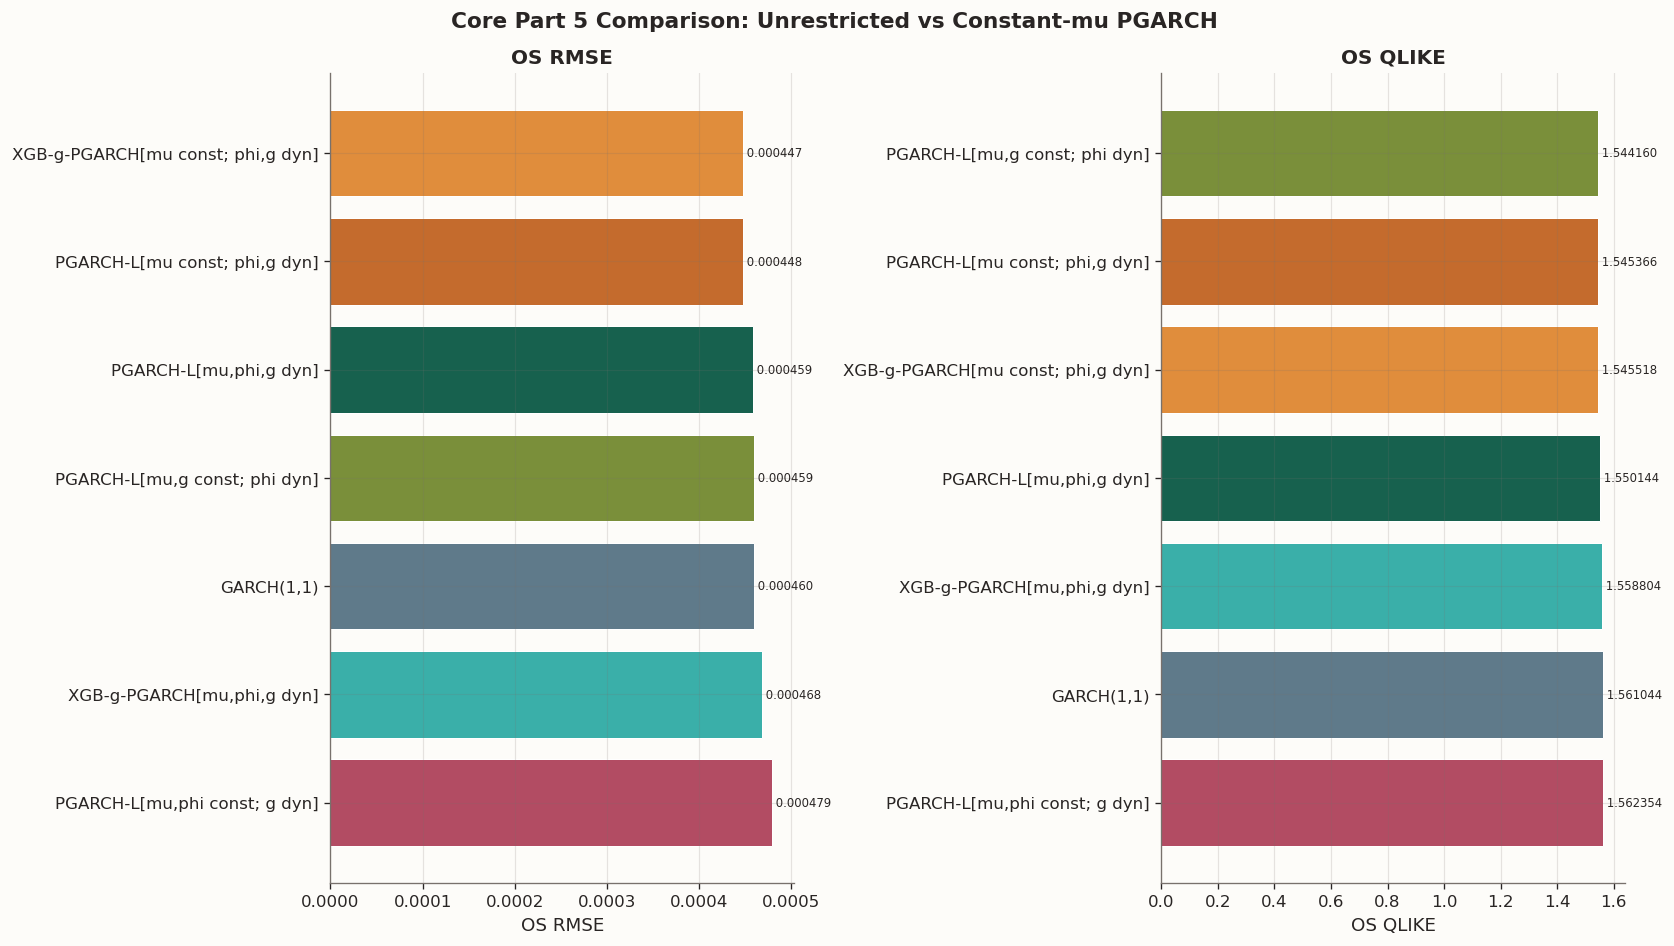

In [ ]:
#| label: core-ranking-chart
#| code-fold: true
#| code-summary: "Focused ranking chart for the core Part 5 models"

core_palette = {
    "GARCH(1,1)": "#5F7A8A",
    "PGARCH-L[mu,phi,g dyn]": "#17614E",
    "XGB-g-PGARCH[mu,phi,g dyn]": "#3AAFA9",
    "PGARCH-L[mu const; phi,g dyn]": "#C46B2D",
    "XGB-g-PGARCH[mu const; phi,g dyn]": "#E08D3C",
    "PGARCH-L[mu,phi const; g dyn]": "#B24C63",
    "PGARCH-L[mu,g const; phi dyn]": "#7A8F3A",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, metric in zip(axes, ["OS RMSE", "OS QLIKE"]):
    chart_df = core_summary_table.sort_values(metric, ascending=True).reset_index(drop=True)
    colors = [core_palette.get(model, "#999999") for model in chart_df["Model"]]
    bars = ax.barh(chart_df["Model"], chart_df[metric], color=colors, edgecolor="white", linewidth=0.6)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    for bar, value in zip(bars, chart_df[metric]):
        ax.text(value, bar.get_y() + bar.get_height() / 2, f" {value:.6f}", va="center", fontsize=7)

fig.suptitle("Core Part 5 Comparison: Unrestricted vs Constant-mu PGARCH", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


The constant-$\mu$ family improves interpretability without requiring a forecasting sacrifice on this sample split. The constant-$\mu$ linear model, `PGARCH-L[mu const; phi,g dyn]`, improves mean out-of-sample QLIKE from `1.550` for the unrestricted linear model, `PGARCH-L[mu,phi,g dyn]`, to `1.545`, and it also improves RMSE from `0.000459` to `0.000448`. The DM comparison against `GARCH(1,1)` remains directional rather than significant at conventional levels, so holding the long-run anchor fixed gives a cleaner specification while preserving benchmark-level forecast quality.

The constant-$\mu$ boosted-$g$ model, `XGB-g-PGARCH[mu const; phi,g dyn]`, lands almost exactly on top of the constant-$\mu$ linear model. Once $\mu$ is fixed, boosting the shock-loading channel alone does not materially improve the three-feature model. The unrestricted boosted-$g$ model remains a useful comparison specification, but it is not the cleanest structural interpretation available under this information set.

The diagnostic $\phi$-only restriction, `PGARCH-L[mu,g const; phi dyn]`, gives the lowest mean QLIKE in this pass and outperforms `GARCH(1,1)` under the DM test on this split. This restriction was added only to locate where the useful adaptation appears after fixing $\mu$. Time-varying persistence appears to carry more of the useful variation than a dynamic long-run anchor does in this three-feature design.


In [ ]:
#| label: pairwise-constmu-table
#| tbl-cap: "Pairwise QLIKE comparisons among the unrestricted and constant-mu PGARCH variants"

pairwise_specs = [
    ("PGARCH-L[mu const; phi,g dyn] vs PGARCH-L[mu,phi,g dyn]", core_model_predictions["PGARCH-L[mu const; phi,g dyn]"], core_model_predictions["PGARCH-L[mu,phi,g dyn]"]),
    (
        "XGB-g-PGARCH[mu const; phi,g dyn] vs XGB-g-PGARCH[mu,phi,g dyn]",
        core_model_predictions["XGB-g-PGARCH[mu const; phi,g dyn]"],
        core_model_predictions["XGB-g-PGARCH[mu,phi,g dyn]"],
    ),
    (
        "PGARCH-L[mu,phi const; g dyn] vs PGARCH-L[mu const; phi,g dyn]",
        core_model_predictions["PGARCH-L[mu,phi const; g dyn]"],
        core_model_predictions["PGARCH-L[mu const; phi,g dyn]"],
    ),
    (
        "PGARCH-L[mu,g const; phi dyn] vs PGARCH-L[mu const; phi,g dyn]",
        core_model_predictions["PGARCH-L[mu,g const; phi dyn]"],
        core_model_predictions["PGARCH-L[mu const; phi,g dyn]"],
    ),
]

pairwise_rows = []
for label, pred_a, pred_b in pairwise_specs:
    dm = diebold_mariano(_qlike_loss(actual_os, pred_a), _qlike_loss(actual_os, pred_b), h=1)
    pairwise_rows.append(
        {
            "Comparison": label,
            "OS QLIKE (A)": qlike(actual_os, pred_a),
            "OS QLIKE (B)": qlike(actual_os, pred_b),
            "DM (QLIKE)": dm["dm_stat"],
            "p-value": dm["p_value"],
        }
    )

pairwise_table = pd.DataFrame(pairwise_rows)
display(style_results_table(pairwise_table, precision=6, index_col="Comparison"))


,OS QLIKE (A),OS QLIKE (B),DM (QLIKE),p-value
Comparison,,,,
"PGARCH-L[mu const; phi,g dyn] vs PGARCH-L[mu,phi,g dyn]",1.545366,1.550144,-0.224011,0.822771
"XGB-g-PGARCH[mu const; phi,g dyn] vs XGB-g-PGARCH[mu,phi,g dyn]",1.545518,1.558804,-0.658173,0.510501
"PGARCH-L[mu,phi const; g dyn] vs PGARCH-L[mu const; phi,g dyn]",1.562354,1.545366,1.860229,0.062997
"PGARCH-L[mu,phi dyn; g const] vs PGARCH-L[mu const; phi,g dyn]",1.544160,1.545366,-0.123386,0.901813


The pairwise DM table shows that the constant-$\mu$ linear model beats the unrestricted linear model directionally, but the improvement is small relative to sampling noise on this single split. The same is true when the unrestricted and constant-$\mu$ boosted-$g$ models are compared. Nevertheless, the constant-$\mu$ extension is more interpretable than the unrestricted PGARCH-L, albeit not producing statistical gain against GARCH(1,1).

The more informative pairwise checks are the diagnostic restrictions inside the constant-$\mu$ family. The $g$-only restriction, `PGARCH-L[mu,phi const; g dyn]`, trails the constant-$\mu$ linear model and sits close to the `GARCH(1,1)` benchmark, which suggests that a dynamic shock-loading channel on its own is not enough. By contrast, the $\phi$-only restriction, `PGARCH-L[mu,g const; phi dyn]`, is essentially tied with the constant-$\mu$ linear model. Taken together, those two comparisons point in the same direction: under the three return feature information set, most of the useful adaptation seems to come from **time-varying persistence**, while a separately dynamic $g_t$ is secondary and a dynamic $\mu_t$ is the least convincing channel structurally.


## Structural Diagnostics

The next table and plots compare how the unrestricted and constant-$\mu$ linear PGARCH specifications allocate variation across the three channels on the test window. In the plot legends below, we shorten the labels to `all dynamic`, `mu fixed`, `g dynamic only`, and `phi dynamic only`. This is the direct check of whether the new family is actually more interpretable, rather than merely competitive in average loss.


In [ ]:
#| label: structural-stats-table
#| tbl-cap: "Out-of-sample channel summaries for the linear PGARCH variants"

dates_os = X_te.index
linear_components_os = {}
structural_rows = []

for name, model in linear_structural_models.items():
    components = model.predict_components(X_pgarch_te.values)
    linear_components_os[name] = components
    structural_rows.append(
        {
            "Model": name,
            "mu mean": np.mean(components["mu"]),
            "mu std": np.std(components["mu"]),
            "phi mean": np.mean(components["phi"]),
            "phi std": np.std(components["phi"]),
            "g mean": np.mean(components["g"]),
            "g std": np.std(components["g"]),
        }
    )

structural_stats_table = pd.DataFrame(structural_rows)
display(style_results_table(structural_stats_table, precision=6, index_col="Model"))


,mu mean,mu std,phi mean,phi std,g mean,g std
Model,,,,,,
"PGARCH-L[mu,phi,g dyn]",0.010582,0.222744,0.900027,0.034148,0.016393,0.013172
"PGARCH-L[mu const; phi,g dyn]",0.002499,0.000000,0.996402,0.038012,0.120397,0.093281
"PGARCH-L[mu,phi const; g dyn]",0.013383,0.000000,0.999860,0.000000,0.123142,0.058814
"PGARCH-L[mu,g const; phi dyn]",0.000141,0.000000,0.983208,0.025070,0.115163,0.000000


The structural table highlights the core issues. The unrestricted linear model assigns substantial variation to the long-run anchor: on the test window $\mu_t$ ranges from essentially zero to several orders of magnitude above the fixed-anchor alternatives. That is hard to reconcile with the interpretation of $\mu_t$ as a long-run variance level when the only inputs are recent return transforms.

Once $\mu$ is fixed, the adjustment moves into $\phi_t$ and, to a lesser extent, $g_t$. The near tie between the $\phi$-only restriction and the constant-$\mu$ linear model, together with the weaker $g$-only restriction, suggests that persistence is doing most of the useful work here. We will see that more clearly in the charts below.


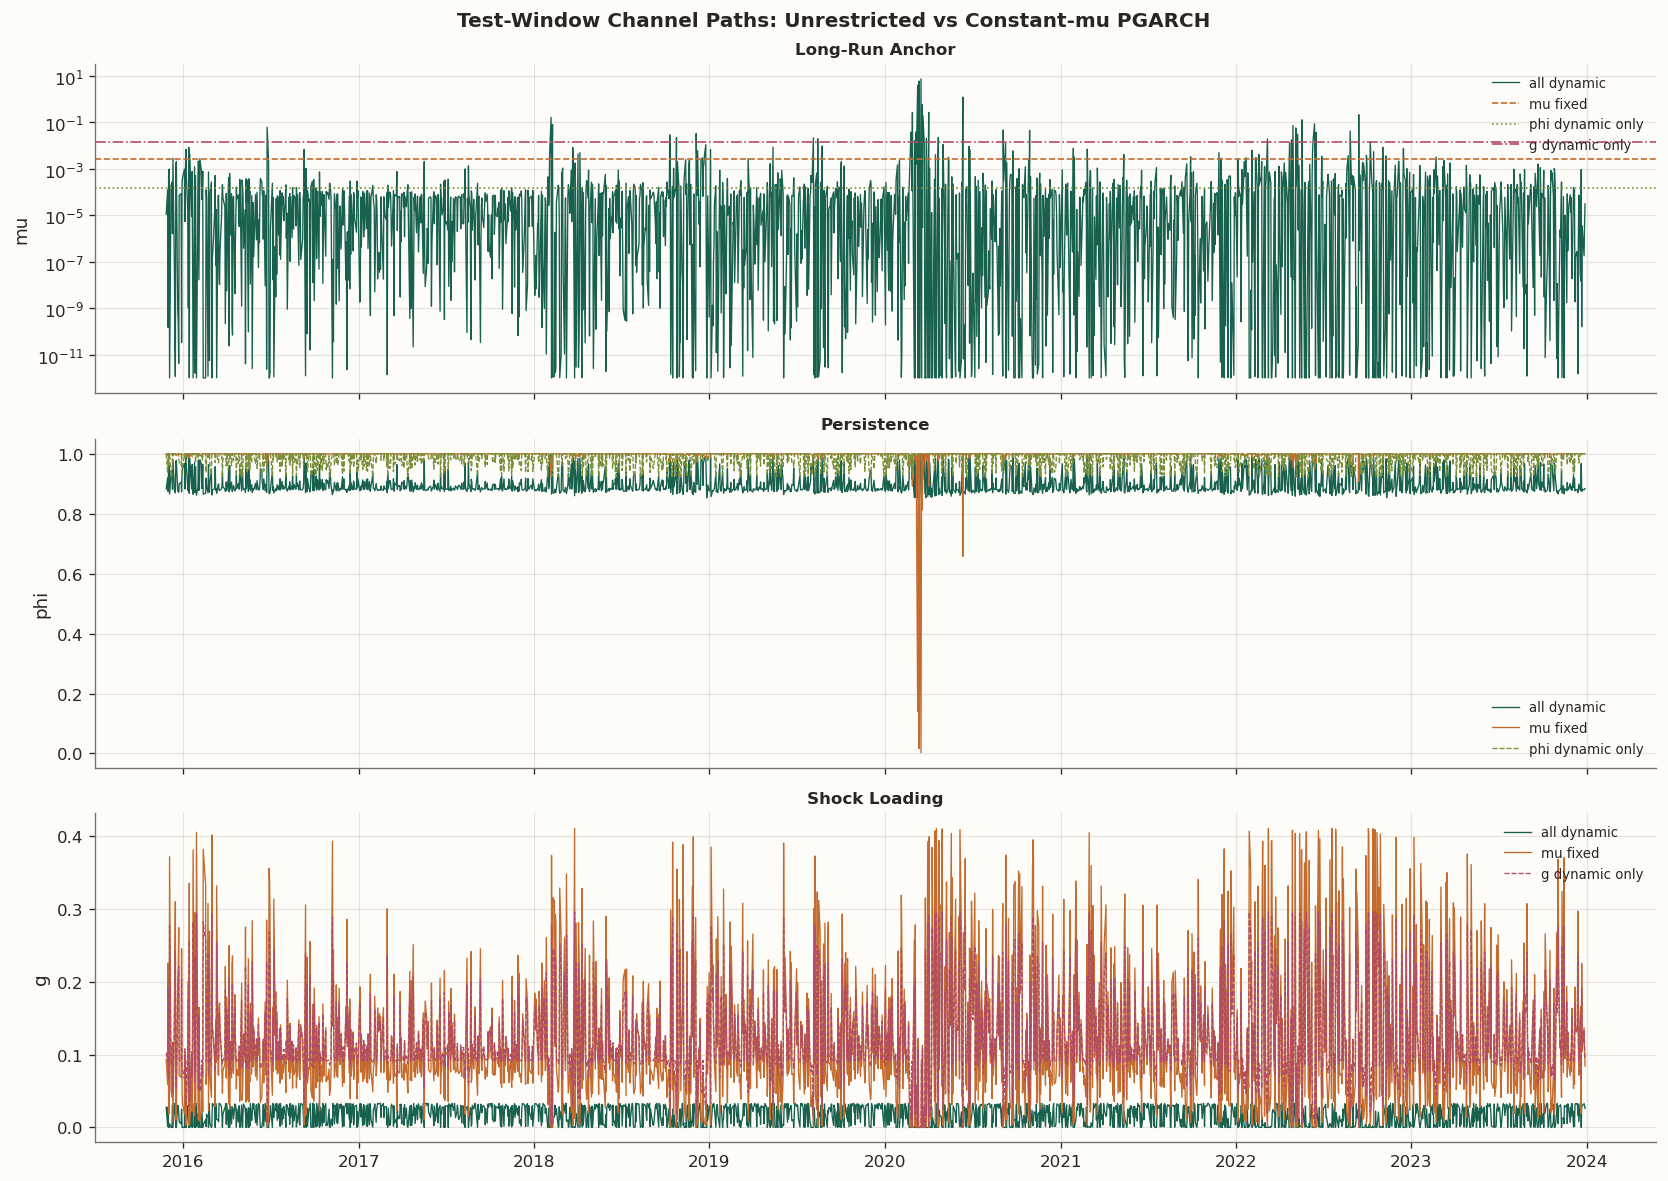

In [ ]:
#| code-fold: true
#| code-summary: "Compare the test-window channel paths for the unrestricted and constant-mu linear PGARCH variants"

dyn = linear_components_os["PGARCH-L[mu,phi,g dyn]"]
constmu = linear_components_os["PGARCH-L[mu const; phi,g dyn]"]
g_only = linear_components_os["PGARCH-L[mu,phi const; g dyn]"]
phi_only = linear_components_os["PGARCH-L[mu,g const; phi dyn]"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(dates_os, dyn["mu"], color="#17614E", linewidth=0.8, label="all dynamic")
axes[0].axhline(constmu["mu"][0], color="#C46B2D", linestyle="--", linewidth=1.0, label="mu fixed")
axes[0].axhline(phi_only["mu"][0], color="#7A8F3A", linestyle=":", linewidth=1.0, label="phi dynamic only")
axes[0].axhline(g_only["mu"][0], color="#B24C63", linestyle="-.", linewidth=1.0, label="g dynamic only")
axes[0].set_yscale("log")
axes[0].set_ylabel("mu")
axes[0].set_title("Long-Run Anchor", fontsize=10, fontweight="bold")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].plot(dates_os, dyn["phi"], color="#17614E", linewidth=0.8, label="all dynamic")
axes[1].plot(dates_os, constmu["phi"], color="#C46B2D", linewidth=0.8, label="mu fixed")
axes[1].plot(dates_os, phi_only["phi"], color="#7A8F3A", linewidth=0.8, linestyle="--", label="phi dynamic only")
axes[1].set_ylabel("phi")
axes[1].set_title("Persistence", fontsize=10, fontweight="bold")
axes[1].legend(loc="lower right", fontsize=8)

axes[2].plot(dates_os, dyn["g"], color="#17614E", linewidth=0.8, label="all dynamic")
axes[2].plot(dates_os, constmu["g"], color="#C46B2D", linewidth=0.8, label="mu fixed")
axes[2].plot(dates_os, g_only["g"], color="#B24C63", linewidth=0.8, linestyle="--", label="g dynamic only")
axes[2].set_ylabel("g")
axes[2].set_title("Shock Loading", fontsize=10, fontweight="bold")
axes[2].legend(loc="upper right", fontsize=8)

fig.suptitle("Test-Window Channel Paths: Unrestricted vs Constant-mu PGARCH", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


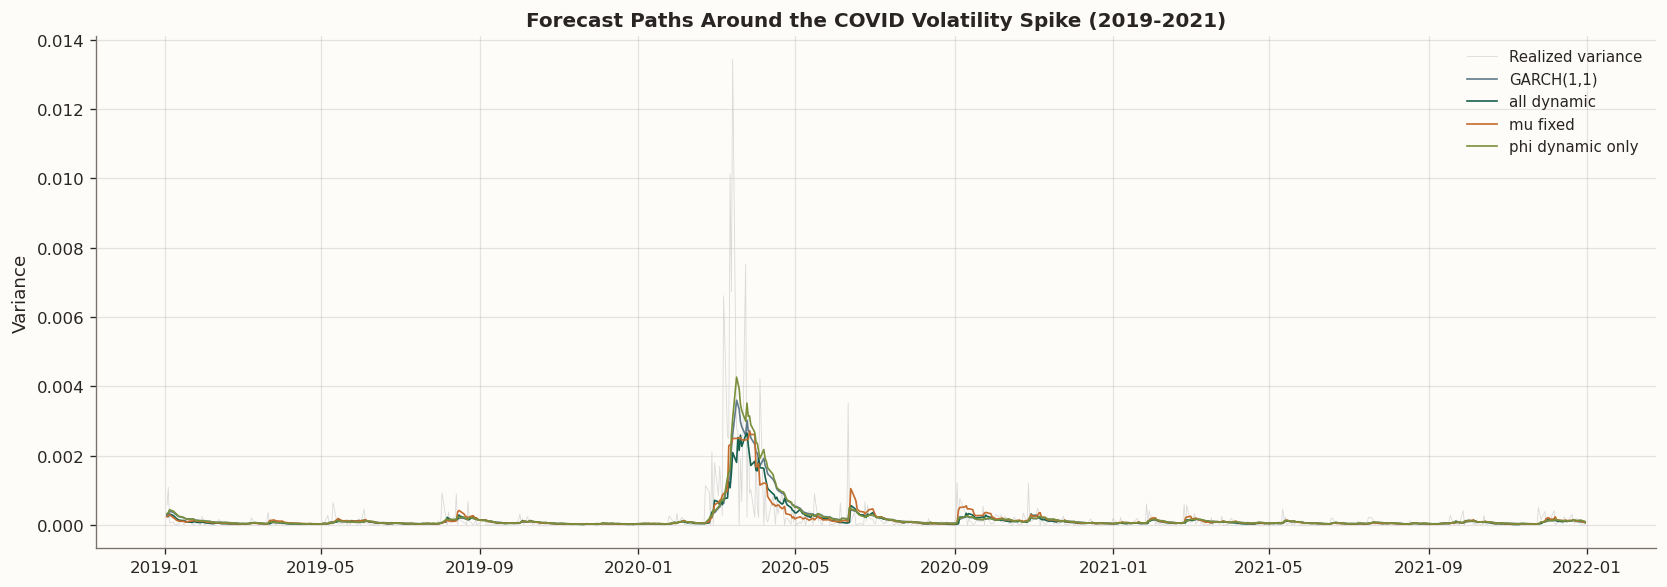

In [ ]:
#| code-fold: true
#| code-summary: "Forecast paths around the COVID volatility spike"

window_start = pd.Timestamp("2019-01-01", tz="UTC")
window_end = pd.Timestamp("2021-12-31", tz="UTC")
mask = (dates_os >= window_start) & (dates_os <= window_end)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_os[mask], actual_os[mask], color="#CCCCCC", linewidth=0.5, alpha=0.7, label="Realized variance")
ax.plot(dates_os[mask], core_model_predictions["GARCH(1,1)"][mask], color="#5F7A8A", linewidth=1.0, label="GARCH(1,1)")
ax.plot(dates_os[mask], core_model_predictions["PGARCH-L[mu,phi,g dyn]"][mask], color="#17614E", linewidth=1.0, label="all dynamic")
ax.plot(
    dates_os[mask],
    core_model_predictions["PGARCH-L[mu const; phi,g dyn]"][mask],
    color="#C46B2D",
    linewidth=1.0,
    label="mu fixed",
)
ax.plot(
    dates_os[mask],
    core_model_predictions["PGARCH-L[mu,g const; phi dyn]"][mask],
    color="#7A8F3A",
    linewidth=1.0,
    label="phi dynamic only",
)

ax.set_ylabel("Variance")
ax.set_title("Forecast Paths Around the COVID Volatility Spike (2019-2021)", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()


## Conclusion

Drawing from our work in [Part 4](../volatility-forecasts-4/) where GARCH(1,1) has a lower QLIKE Loss than our STES-family models, we explore the structural advantage of GARCH and moves to generalize its parameters from a constant to other functional form, resulting in an unrestricted PGARCH model. However, we immediately see the problem with blindly applying our three return features to explain all the reparametrized GARCH parameters. Our return features are too fast to model the slow-moving dynamic of long-run variance level $\mu$. We therefore test imposing different restrictions on the PGARCH model.

The constant-$\mu$ family gives a clearer statement of what the three return features can and cannot do. They are informative about fast volatility adaptation. They are not a convincing basis for a dynamic long-run variance channel. Within that disciplined family, the evidence points more toward time-varying persistence than toward time-varying shock loading alone.

The three-feature PGARCH idea remains promising. Several PGARCH variants match or beat `GARCH(1,1)` on mean out-of-sample QLIKE. The more disciplined conclusion, however, is limited: with only lagged return, lagged absolute return, and lagged squared return available, a dynamic long-run anchor is not cleanly identified. The constant-$\mu$ PGARCH variants therefore provide the cleaner formulation.

If the goal is a genuinely dynamic long-run channel, the information set has to change. Richer realized-volatility, calendar, or market-state features are needed before a time-varying $\mu_t$ can be interpreted as more than a repackaging of recent shocks. Part 6 of this series is therefore motivated not by a need to discard the Part 5 PGARCH decomposition, but by the need to give its long-run channel a more credible set of predictors.

Stay tuned.

## Appendix: PGARCH Derivative Details

This appendix collects the unrestricted PGARCH derivative formulas used in the model code. The constant-$\mu$ and other channel-restricted variants in the main text are obtained by fixing the non-intercept feature coefficients of the corresponding channel at zero while retaining the intercept term, so no new derivative machinery is required.

### Loss functions

We consider two training losses over the effective sample $t = 1, \ldots, T-1$ (excluding the warm-start $h_0$), with $N = T-1$:

**MSE:**
$$
L_{\text{MSE}} = \frac{1}{N}\sum_{t=1}^{T-1}(y_t - h_t)^2, \qquad u_t = \frac{2(h_t - y_t)}{N}, \qquad v_t = \frac{2}{N}
$$

**QLIKE:**
$$
L_{\text{QLIKE}} = \frac{1}{N}\sum_{t=1}^{T-1}\left(\log h_t + \frac{y_t}{h_t}\right), \qquad u_t = \frac{1}{N}\left(\frac{1}{h_t} - \frac{y_t}{h_t^2}\right), \qquad v_t = \frac{1}{N}\left(-\frac{1}{h_t^2} + \frac{2y_t}{h_t^3}\right)
$$

### Jacobian recursion (Linear PGARCH)

Let $\theta = [w_\mu, w_\phi, w_g]$ and $\tilde{x}_{t-1} = [1, x_{t-1}]$. Define block-embedded vectors $d_t^\mu$, $d_t^\phi$, $d_t^g$ that place $\tilde{x}_{t-1}$ in the appropriate block of $\theta$ and zeros elsewhere.

The component Jacobians use the link derivatives:

$$
J_t^\mu = \sigma(a_t) d_t^\mu, \qquad
J_t^\phi = (\phi_{\max} - \phi_{\min}) s_b(1-s_b) d_t^\phi, \qquad
J_t^g = (g_{\max} - g_{\min}) s_c(1-s_c) d_t^g
$$

The intermediate quantity $q_t = g_t y_{t-1} + (1-g_t)h_{t-1}$ has Jacobian

$$
J_t^q = (1 - g_t) J_{t-1} + (y_{t-1} - h_{t-1}) J_t^g
$$

The state Jacobian follows from $h_t = (1-\phi_t)\mu_t + \phi_t q_t$:

$$
J_t = (1-\phi_t) J_t^\mu + (q_t - \mu_t) J_t^\phi + \phi_t J_t^q, \qquad J_0 = 0
$$

### Hessian recursion (Linear PGARCH)

The link Hessians are rank-one matrices:

$$
H_t^\mu = s_a(1-s_a) d_t^\mu (d_t^\mu)^\top, \qquad
H_t^\phi = (\phi_{\max}-\phi_{\min}) s_b(1-s_b)(1-2s_b) d_t^\phi (d_t^\phi)^\top
$$

and similarly for $H_t^g$. The Hessian recursions are:

$$
H_t^q = (1-g_t) H_{t-1} + (y_{t-1}-h_{t-1}) H_t^g - J_t^g J_{t-1}^\top - J_{t-1}(J_t^g)^\top
$$

$$
H_t = (1-\phi_t) H_t^\mu + (q_t-\mu_t) H_t^\phi + \phi_t H_t^q + J_t^\phi(J_t^q - J_t^\mu)^\top + (J_t^q - J_t^\mu)(J_t^\phi)^\top, \qquad H_0 = 0
$$

### Gradient and Hessian of the training loss

$$
\nabla_\theta L = \sum_{t=1}^{T-1} u_t J_t, \qquad
\nabla_\theta^2 L = \sum_{t=1}^{T-1}\left(v_t J_t J_t^\top + u_t H_t\right)
$$

### Boosted $g$-channel adjoint gradient (fixed $\mu_t$ and $\phi_t$)

With $\mu_t$, $\phi_t$ fixed and only $c_t$ (the raw score for $g_t$) variable:

- **Local impulse:** $\delta_s = \phi_s(y_s - h_s) C_s$ where $C_s = (g_{\max}-g_{\min}) \sigma(c_s)(1-\sigma(c_s))$.
- **State propagation:** $\rho_s = \phi_s(1-g_s)$.
- **Adjoint:** $\lambda_{T-1} = u_{T-1}$; $\lambda_t = u_t + \rho_t \lambda_{t+1}$ for $t = T-2, \ldots, 0$.
- **Row gradient:** $G_s = \lambda_{s+1}\,\delta_s$ for $s = 0, \ldots, T-2$; $G_{T-1} = 0$.

### Boosted $g$-channel Hessian approximation (fixed $\mu_t$ and $\phi_t$)

**MSE (Gauss-Newton):**
$$
H_s \approx \sum_{t=s+1}^{T-1} \frac{2}{N}\left(\frac{\partial h_t}{\partial c_s}\right)^2
$$

**QLIKE (Fisher-style):** replace $2/N$ with $w_t = \operatorname{clip}(1/(N h_t^2), \varepsilon, w_{\max})$.

Both are computed efficiently via a backward accumulation:

$$
F_{T-1} = w_{T-1}, \qquad F_t = w_t + \rho_t^2 F_{t+1}, \qquad H_s = \delta_s^2 F_{s+1}
$$